# ADHD EEG Universal Deep Learning Pipeline

**Input flow**

ZIP / MAT / EDF / CSV → Dataset Validator → EEG Standardization → Common Preprocessing → Model → Prediction + Confidence

This notebook is designed for EEG datasets whose recordings can be associated with a subject ID and a binary label such as **ADHD/Control**. It does not invent labels when they cannot be determined.

### Main safeguards
- Subject-wise train/validation/test split **before windowing**
- Train-only channel standardization
- 4-second windows with 50% overlap by default
- 1–45 Hz band-pass and 50 Hz notch by default
- Common-average reference (CAR) on the continuous recording
- Robust artifact clipping using training-derived channel statistics
- Class weighting instead of combining sampler + class weights
- Early stopping, learning-rate reduction and best-checkpoint restore
- Window-level and subject-level metrics
- ROC-AUC, PR-AUC, sensitivity, specificity, F1, balanced accuracy
- Confusion matrix and ROC/PR plots
- Confidence and entropy for predictions
- Model-specific explainability


# Model 3 — Universal EEG CNN + Transformer

In [5]:

# =========================
# 1. Install / imports
# =========================
%pip -q install mne scipy pandas scikit-learn matplotlib seaborn

import os, re, json, math, zipfile, warnings, random, shutil
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import signal
from scipy.io import loadmat
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score, confusion_matrix,
    classification_report, roc_curve, precision_recall_curve
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import mne

warnings.filterwarnings("ignore")
print("TensorFlow:", tf.__version__)
print("MNE:", mne.__version__)


TensorFlow: 2.20.0
MNE: 1.13.2


In [6]:

# =========================
# 2. Configuration
# =========================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Leave None for automatic discovery under /content.
# Or set an exact path, for example:
# DATA_PATH = "/content/ADHD_EEG_19ch_128Hz_Colab_Ready.zip"
DATA_PATH = "/content/A Dataset of EEG Signals from Adults with ADHD and Healthy Controls Resting State, Cognitive function, and Sound Listening Paradigm.zip"

WORK_DIR = Path("/content/eeg_project")
EXTRACT_DIR = WORK_DIR / "extracted"
WORK_DIR.mkdir(parents=True, exist_ok=True)
EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

WINDOW_SECONDS = 4
OVERLAP = 0.50
LOW_HZ = 1.0
HIGH_HZ = 45.0
NOTCH_HZ = 50.0

TEST_SIZE = 0.20
VAL_SIZE = 0.20

EPOCHS = 60
BATCH_SIZE = 64
LEARNING_RATE = 1e-3

# Safety limits. Increase only if your recordings are very large.
MAX_FILES_TO_SCAN = 5000

print("Configuration ready.")


Configuration ready.


In [8]:

# =========================
# 3. Dataset discovery and ZIP extraction
# =========================
SUPPORTED = {".zip", ".mat", ".edf", ".csv", ".tsv", ".npy", ".npz"}

def discover_dataset(root="/content", explicit_path=DATA_PATH):
    if explicit_path:
        p = Path(explicit_path)
        if not p.exists():
            raise FileNotFoundError(f"DATA_PATH does not exist: {p}")
        return p

    candidates = []
    for p in Path(root).rglob("*"):
        if len(candidates) >= MAX_FILES_TO_SCAN:
            break
        if p.is_file() and p.suffix.lower() in SUPPORTED:
            # Skip generated project files
            if WORK_DIR in p.parents:
                continue
            candidates.append(p)

    if not candidates:
        raise FileNotFoundError(
            "No ZIP/MAT/EDF/CSV/TSV/NPY/NPZ dataset was found under /content. "
            "Upload your dataset ZIP/MAT/EDF/CSV using Colab's left Files panel, "
            "then rerun this cell."
        )

    # Prefer ZIP because it commonly contains the full dataset.
    zips = [p for p in candidates if p.suffix.lower() == ".zip"]
    chosen = max(zips, key=lambda p: p.stat().st_size) if zips else candidates[0]
    return chosen

DATASET = discover_dataset(DATA_PATH)
print("Selected dataset:", DATASET)
print("Size (MB):", round(DATASET.stat().st_size / 1024**2, 2))

if DATASET.suffix.lower() == ".zip":
    print("Extracting ZIP...")
    with zipfile.ZipFile(DATASET, "r") as z:
        bad = z.testzip()
        if bad is not None:
            raise ValueError(f"ZIP integrity check failed at: {bad}")
        z.extractall(EXTRACT_DIR)
    SEARCH_ROOT = EXTRACT_DIR
else:
    SEARCH_ROOT = DATASET.parent

files = [p for p in SEARCH_ROOT.rglob("*") if p.is_file() and p.suffix.lower() in SUPPORTED]
print(f"Found {len(files)} supported files.")
for p in files[:20]:
    print(" -", p.relative_to(SEARCH_ROOT))


Selected dataset: /content/A Dataset of EEG Signals from Adults with ADHD and Healthy Controls Resting State, Cognitive function, and Sound Listening Paradigm.zip
Size (MB): 50.15
Extracting ZIP...
Found 4 supported files.
 - A Dataset of EEG Signals from Adults with ADHD and Healthy Controls Resting State, Cognitive function, and Sound Listening Paradigm/EEG/FADHD.mat
 - A Dataset of EEG Signals from Adults with ADHD and Healthy Controls Resting State, Cognitive function, and Sound Listening Paradigm/EEG/MADHD.mat
 - A Dataset of EEG Signals from Adults with ADHD and Healthy Controls Resting State, Cognitive function, and Sound Listening Paradigm/EEG/MC.mat
 - A Dataset of EEG Signals from Adults with ADHD and Healthy Controls Resting State, Cognitive function, and Sound Listening Paradigm/EEG/FC.mat


In [20]:

# ============================================================
# UNIVERSAL EEG DATASET PARSER
# ============================================================
#
# Supports:
#   .mat
#   .csv
#   .tsv
#   .edf
#   .npy
#   .npz
#
# Designed to handle:
#   - 2-D EEG arrays
#   - 3-D EEG arrays
#   - MATLAB object arrays
#   - MATLAB nested structures
#   - different channel/sample orientations
#   - labeled and unlabeled datasets
#
# IMPORTANT:
# The parser does NOT invent labels.
# If ADHD/Control cannot be identified, label = -1.
#
# ============================================================

import os
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from scipy.io import loadmat


# ============================================================
# 1. CONFIGURATION
# ============================================================

# Change this to the folder containing your uploaded dataset.
DATASET_DIR = Path(
    "/content/eeg_project/extracted"
)

# Default sampling frequency used ONLY when the dataset does
# not provide sampling-rate information.
DEFAULT_SFREQ = 128.0

# Minimum recording duration.
MIN_RECORDING_SECONDS = 2

# Maximum reasonable EEG channels.
MAX_CHANNELS = 256

# Minimum number of samples.
MIN_SAMPLES = 256


# ============================================================
# 2. LABEL VOCABULARY
# ============================================================

POSITIVE_LABELS = [
    "adhd",
    "patient",
    "patients",
    "case",
    "cases",
    "clinical",
    "positive",
    "disease",
    "affected",
    "diagnosed"
]

NEGATIVE_LABELS = [
    "control",
    "controls",
    "ctrl",
    "healthy",
    "health",
    "normal",
    "hc",
    "healthycontrol",
    "healthycontrols",
    "negative"
]


# ============================================================
# 3. LABEL DETECTION
# ============================================================

def normalize_text(text):

    text = str(text).lower()

    text = text.replace("-", "_")
    text = text.replace(" ", "_")

    return text


def infer_label(text):

    text = normalize_text(text)

    # --------------------------------------------------------
    # First check control/healthy terms.
    # --------------------------------------------------------

    for token in NEGATIVE_LABELS:

        if re.search(
            rf"(?<![a-z]){re.escape(token)}(?![a-z])",
            text
        ):

            return 0

    # --------------------------------------------------------
    # Then ADHD/patient terms.
    # --------------------------------------------------------

    for token in POSITIVE_LABELS:

        if re.search(
            rf"(?<![a-z]){re.escape(token)}(?![a-z])",
            text
        ):

            return 1

    return -1


# ============================================================
# 4. SUBJECT ID DETECTION
# ============================================================

def infer_subject_id(path):

    path = Path(path)

    name = path.stem

    patterns = [

        r"(?:subject|sub|participant|patient|person|"
        r"volunteer|individual|id)[_\-\s]*([a-zA-Z0-9]+)",

        r"\b([a-zA-Z]{0,5}\d{1,5})\b"

    ]

    for pattern in patterns:

        match = re.search(
            pattern,
            name,
            re.IGNORECASE
        )

        if match:

            return match.group(1)

    # If nothing is found, use filename.
    return name


# ============================================================
# 5. SAMPLING FREQUENCY DETECTION
# ============================================================

def detect_sfreq(mat):

    possible_names = [

        "sfreq",
        "samplingrate",
        "sampling_rate",
        "samplerate",
        "sample_rate",
        "fs",
        "frequency",
        "freq"

    ]

    for key, value in mat.items():

        if key.startswith("__"):
            continue

        key_normalized = (
            key.lower()
            .replace("_", "")
            .replace(" ", "")
        )

        if any(
            name.replace("_", "") in key_normalized
            for name in possible_names
        ):

            try:

                arr = np.asarray(value).squeeze()

                if arr.size == 1:

                    fs = float(arr)

                    if 10 <= fs <= 5000:

                        return fs

            except Exception:
                pass

    return None


# ============================================================
# 6. NUMERIC ARRAY TEST
# ============================================================

def is_numeric_array(x):

    try:

        arr = np.asarray(x)

        return (
            arr.size > 0
            and np.issubdtype(
                arr.dtype,
                np.number
            )
        )

    except Exception:

        return False


# ============================================================
# 7. FIND NUMERIC ARRAYS RECURSIVELY
# ============================================================

def find_numeric_arrays(
    obj,
    path="root",
    results=None,
    depth=0,
    max_depth=8
):

    if results is None:

        results = []

    if depth > max_depth:

        return results


    # --------------------------------------------------------
    # NumPy array
    # --------------------------------------------------------

    if isinstance(obj, np.ndarray):

        # Numeric ndarray
        if np.issubdtype(obj.dtype, np.number):

            if obj.ndim >= 1:

                results.append(
                    {
                        "path": path,
                        "array": obj
                    }
                )

                return results


        # Object ndarray
        if obj.dtype == object:

            for index, value in np.ndenumerate(obj):

                find_numeric_arrays(
                    value,
                    path=f"{path}{index}",
                    results=results,
                    depth=depth + 1,
                    max_depth=max_depth
                )

            return results


    # --------------------------------------------------------
    # MATLAB structure
    # --------------------------------------------------------

    if hasattr(obj, "_fieldnames"):

        for field in obj._fieldnames:

            try:

                value = getattr(
                    obj,
                    field
                )

                find_numeric_arrays(
                    value,
                    path=f"{path}.{field}",
                    results=results,
                    depth=depth + 1,
                    max_depth=max_depth
                )

            except Exception:
                pass

        return results


    # --------------------------------------------------------
    # Dictionary
    # --------------------------------------------------------

    if isinstance(obj, dict):

        for key, value in obj.items():

            find_numeric_arrays(
                value,
                path=f"{path}.{key}",
                results=results,
                depth=depth + 1,
                max_depth=max_depth
            )

    return results


# ============================================================
# 8. SCORE POSSIBLE EEG ARRAYS
# ============================================================

def score_eeg_array(arr):

    try:

        arr = np.asarray(arr)

        if not np.issubdtype(
            arr.dtype,
            np.number
        ):

            return -999999

        if arr.ndim not in [2, 3]:

            return -999999

        score = 0


        # ----------------------------------------------------
        # 2-D
        # ----------------------------------------------------

        if arr.ndim == 2:

            a, b = arr.shape

            # EEG usually has many more samples than channels.
            if a >= MIN_SAMPLES:
                score += 20

            if b <= MAX_CHANNELS:
                score += 20

            if b < a:
                score += 20


        # ----------------------------------------------------
        # 3-D
        # ----------------------------------------------------

        elif arr.ndim == 3:

            a, b, c = arr.shape

            # Common EEG structure:
            #
            # recordings × samples × channels
            #
            if b >= MIN_SAMPLES:
                score += 25

            if c <= MAX_CHANNELS:
                score += 20

            if c <= 64:
                score += 10

            # Alternative:
            #
            # channels × samples × recordings

            if a <= MAX_CHANNELS:
                score += 5


        # ----------------------------------------------------
        # Reject pathological arrays
        # ----------------------------------------------------

        if arr.size < MIN_SAMPLES:

            return -999999


        # Reject extremely high dimensions.
        if arr.ndim > 3:

            return -999999


        return score

    except Exception:

        return -999999


# ============================================================
# 9. ORIENT 2-D EEG DATA
# ============================================================

def orient_2d_eeg(arr):

    arr = np.asarray(
        arr,
        dtype=np.float32
    )

    if arr.ndim != 2:

        raise ValueError(
            f"Expected 2-D array, got {arr.shape}"
        )


    rows, cols = arr.shape


    # --------------------------------------------------------
    # Case 1:
    #
    # samples × channels
    #
    # Example:
    # 10000 × 19
    # --------------------------------------------------------

    if (
        rows >= MIN_SAMPLES
        and cols <= MAX_CHANNELS
        and rows > cols
    ):

        return arr


    # --------------------------------------------------------
    # Case 2:
    #
    # channels × samples
    #
    # Example:
    # 19 × 10000
    # --------------------------------------------------------

    if (
        cols >= MIN_SAMPLES
        and rows <= MAX_CHANNELS
        and cols > rows
    ):

        return arr.T


    raise ValueError(
        f"Could not determine EEG orientation: "
        f"{arr.shape}"
    )


# ============================================================
# 10. CONVERT 3-D DATA INTO RECORDINGS
# ============================================================

def convert_3d_to_recordings(arr):

    arr = np.asarray(
        arr,
        dtype=np.float32
    )

    if arr.ndim != 3:

        raise ValueError(
            f"Expected 3-D array, got {arr.shape}"
        )


    a, b, c = arr.shape

    recordings = []


    # ========================================================
    # Pattern A
    #
    # recordings × samples × channels
    #
    # Example:
    #
    # 27 × 7680 × 2
    #
    # ========================================================

    if (
        b >= MIN_SAMPLES
        and c <= MAX_CHANNELS
    ):

        for i in range(a):

            signal = arr[i]

            if signal.shape[0] >= MIN_SAMPLES:

                recordings.append(
                    orient_2d_eeg(signal)
                )

        return recordings


    # ========================================================
    # Pattern B
    #
    # channels × samples × recordings
    #
    # Example:
    #
    # 19 × 10000 × 20
    #
    # ========================================================

    if (
        a <= MAX_CHANNELS
        and b >= MIN_SAMPLES
    ):

        for i in range(c):

            signal = arr[:, :, i]

            recordings.append(
                orient_2d_eeg(signal)
            )

        return recordings


    raise ValueError(
        f"Unsupported 3-D EEG structure: "
        f"{arr.shape}"
    )


# ============================================================
# 11. LOAD MATLAB FILE
# ============================================================

def read_mat_file(path):

    path = Path(path)

    mat = loadmat(
        str(path),
        struct_as_record=False,
        squeeze_me=False
    )

    sfreq = detect_sfreq(mat)


    # --------------------------------------------------------
    # Find all numeric arrays recursively
    # --------------------------------------------------------

    candidates = []

    for key, value in mat.items():

        if key.startswith("__"):
            continue

        found = find_numeric_arrays(
            value,
            path=key
        )

        candidates.extend(found)


    # --------------------------------------------------------
    # Score candidates
    # --------------------------------------------------------

    scored = []

    for candidate in candidates:

        arr = candidate["array"]

        score = score_eeg_array(arr)

        if score > 0:

            scored.append(
                (
                    score,
                    arr.size,
                    candidate["path"],
                    arr
                )
            )


    if not scored:

        raise ValueError(
            "No usable numeric EEG array found."
        )


    # Largest/highest scoring array
    scored.sort(
        key=lambda x: (x[0], x[1]),
        reverse=True
    )

    _, _, selected_path, selected_array = scored[0]


    print(
        f"Selected EEG array: {selected_path} "
        f"shape={selected_array.shape}"
    )


    # --------------------------------------------------------
    # Convert to recordings
    # --------------------------------------------------------

    if selected_array.ndim == 2:

        recordings = [
            orient_2d_eeg(selected_array)
        ]

    elif selected_array.ndim == 3:

        recordings = convert_3d_to_recordings(
            selected_array
        )

    else:

        raise ValueError(
            f"Unsupported EEG dimension: "
            f"{selected_array.ndim}"
        )


    return recordings, sfreq


# ============================================================
# 12. READ CSV / TSV
# ============================================================

def read_csv_file(path):

    path = Path(path)

    try:

        df = pd.read_csv(
            path
        )

    except Exception:

        df = pd.read_csv(
            path,
            sep=None,
            engine="python"
        )


    # Keep numeric columns only.
    numeric = df.select_dtypes(
        include=[np.number]
    )


    # Remove obvious time/index columns.
    remove = []

    for col in numeric.columns:

        name = str(col).lower().strip()

        if name in [
            "time",
            "timestamp",
            "sample",
            "index"
        ]:

            remove.append(col)


    if remove:

        numeric = numeric.drop(
            columns=remove
        )


    if numeric.shape[1] < 1:

        raise ValueError(
            "No numeric EEG columns found."
        )


    arr = numeric.to_numpy(
        dtype=np.float32
    )


    return [
        orient_2d_eeg(arr)
    ], None


# ============================================================
# 13. READ NPY / NPZ
# ============================================================

def read_numpy_file(path):

    path = Path(path)

    if path.suffix.lower() == ".npy":

        arr = np.load(
            path,
            allow_pickle=False
        )

        arrays = [arr]

    else:

        data = np.load(
            path,
            allow_pickle=False
        )

        arrays = [
            data[key]
            for key in data.files
        ]


    candidates = [
        arr
        for arr in arrays
        if (
            isinstance(arr, np.ndarray)
            and np.issubdtype(
                arr.dtype,
                np.number
            )
            and arr.ndim in [2, 3]
        )
    ]


    if not candidates:

        raise ValueError(
            "No usable numeric EEG array found."
        )


    arr = max(
        candidates,
        key=lambda x: x.size
    )


    if arr.ndim == 2:

        recordings = [
            orient_2d_eeg(arr)
        ]

    else:

        recordings = convert_3d_to_recordings(
            arr
        )


    return recordings, None


# ============================================================
# 14. READ EDF
# ============================================================

def read_edf_file(path):

    try:

        import mne

    except ImportError:

        raise ImportError(
            "Install MNE first:\n"
            "!pip install mne"
        )


    raw = mne.io.read_raw_edf(
        str(path),
        preload=True,
        verbose="ERROR"
    )


    data = raw.get_data().T.astype(
        np.float32
    )


    sfreq = float(
        raw.info["sfreq"]
    )


    ch_names = list(
        raw.ch_names
    )


    return [
        orient_2d_eeg(data)
    ], sfreq, ch_names


# ============================================================
# 15. UNIVERSAL FILE READER
# ============================================================

def read_eeg_file(path):

    path = Path(path)

    extension = path.suffix.lower()


    if extension == ".mat":

        recordings, sfreq = read_mat_file(
            path
        )

        ch_names = None


    elif extension in [
        ".csv",
        ".tsv"
    ]:

        recordings, sfreq = read_csv_file(
            path
        )

        ch_names = None


    elif extension in [
        ".npy",
        ".npz"
    ]:

        recordings, sfreq = read_numpy_file(
            path
        )

        ch_names = None


    elif extension == ".edf":

        recordings, sfreq, ch_names = (
            read_edf_file(path)
        )


    else:

        raise ValueError(
            f"Unsupported file type: "
            f"{extension}"
        )


    if sfreq is None:

        sfreq = DEFAULT_SFREQ


    return recordings, sfreq, ch_names


# ============================================================
# 16. FIND ALL EEG FILES
# ============================================================

SUPPORTED_EXTENSIONS = {
    ".mat",
    ".csv",
    ".tsv",
    ".edf",
    ".npy",
    ".npz"
}


def find_eeg_files(directory):

    directory = Path(directory)

    files = []

    for path in directory.rglob("*"):

        if (
            path.is_file()
            and path.suffix.lower()
            in SUPPORTED_EXTENSIONS
        ):

            files.append(path)


    return sorted(files)


# ============================================================
# 17. BUILD UNIVERSAL RECORDINGS LIST
# ============================================================

def parse_dataset(directory):

    files = find_eeg_files(
        directory
    )


    print(
        f"Found {len(files)} EEG files."
    )


    records = []

    errors = []


    for file_index, path in enumerate(files):

        print("\n" + "=" * 80)

        print(
            f"[{file_index + 1}/{len(files)}]"
        )

        print(
            "FILE:",
            path
        )


        try:

            recordings, sfreq, ch_names = (
                read_eeg_file(path)
            )


            # ------------------------------------------------
            # Determine label
            # ------------------------------------------------

            label = infer_label(
                str(path)
            )


            # ------------------------------------------------
            # Determine subject ID
            # ------------------------------------------------

            base_subject = (
                infer_subject_id(path)
            )


            # ------------------------------------------------
            # Convert every recording
            # ------------------------------------------------

            for recording_index, signal in enumerate(
                recordings
            ):

                signal = np.asarray(
                    signal,
                    dtype=np.float32
                )


                if signal.ndim != 2:

                    continue


                n_samples = signal.shape[0]

                n_channels = signal.shape[1]


                if n_samples < MIN_SAMPLES:

                    continue


                duration = (
                    n_samples / sfreq
                )


                if duration < MIN_RECORDING_SECONDS:

                    continue


                recording_id = (
                    f"{path.stem}_"
                    f"rec_{recording_index:04d}"
                )


                records.append({

                    "file": str(path),

                    "filename": path.name,

                    "subject_id": base_subject,

                    "recording_id": recording_id,

                    "label": label,

                    "label_name": (
                        "ADHD"
                        if label == 1
                        else
                        "CONTROL"
                        if label == 0
                        else
                        "UNKNOWN"
                    ),

                    "sfreq": float(sfreq),

                    "n_samples": n_samples,

                    "n_channels": n_channels,

                    "duration_seconds": duration,

                    "ch_names": ch_names,

                    "data": signal

                })


            print(
                f"Extracted {len(recordings)} "
                f"recording(s)"
            )


        except Exception as e:

            errors.append({

                "file": str(path),

                "error": str(e)

            })


            print(
                "ERROR:",
                e
            )


    return records, errors


# ============================================================
# 18. RUN PARSER
# ============================================================

records, errors = parse_dataset(
    DATASET_DIR
)


# ============================================================
# 19. RESULTS
# ============================================================

print("\n")
print("=" * 80)
print("FINAL PARSER RESULT")
print("=" * 80)

print(
    "Successfully parsed recordings:",
    len(records)
)

print(
    "Failed files:",
    len(errors)
)


# ============================================================
# 20. ERROR REPORT
# ============================================================

if errors:

    print("\nFAILED FILES:")

    for error in errors[:20]:

        print(
            "\nFILE:",
            error["file"]
        )

        print(
            "ERROR:",
            error["error"]
        )


# ============================================================
# 21. CREATE METADATA TABLE
# ============================================================

if records:

    metadata = pd.DataFrame([

        {
            key: value
            for key, value in record.items()
            if key not in [
                "data",
                "ch_names"
            ]
        }

        for record in records

    ])


    print("\nMetadata shape:")
    print(
        metadata.shape
    )


    print("\nFirst 10 records:")

    display(
        metadata.head(10)
    )


    print("\nLabel distribution:")

    print(
        metadata["label_name"].value_counts()
    )


    print("\nSampling frequencies:")

    print(
        metadata["sfreq"].value_counts()
    )


    print("\nChannel counts:")

    print(
        metadata["n_channels"].value_counts()
    )


else:

    raise RuntimeError(
        "No usable EEG recordings were parsed. "
        "Check the FAILED FILES section above."
    )

Found 4 EEG files.

[1/4]
FILE: /content/eeg_project/extracted/A Dataset of EEG Signals from Adults with ADHD and Healthy Controls Resting State, Cognitive function, and Sound Listening Paradigm/EEG/FADHD.mat
Selected EEG array: FADHD(0, 3) shape=(11, 11520, 2)
Extracted 11 recording(s)

[2/4]
FILE: /content/eeg_project/extracted/A Dataset of EEG Signals from Adults with ADHD and Healthy Controls Resting State, Cognitive function, and Sound Listening Paradigm/EEG/FC.mat
Selected EEG array: FC(0, 3) shape=(13, 11520, 2)
Extracted 13 recording(s)

[3/4]
FILE: /content/eeg_project/extracted/A Dataset of EEG Signals from Adults with ADHD and Healthy Controls Resting State, Cognitive function, and Sound Listening Paradigm/EEG/MADHD.mat
Selected EEG array: MADHD(0, 3) shape=(27, 11520, 2)
Extracted 27 recording(s)

[4/4]
FILE: /content/eeg_project/extracted/A Dataset of EEG Signals from Adults with ADHD and Healthy Controls Resting State, Cognitive function, and Sound Listening Paradigm/EEG/

,file,filename,subject_id,recording_id,label,label_name,sfreq,n_samples,n_channels,duration_seconds
0,/content/eeg_project/extracted/A Dataset of EE...,FADHD.mat,FADHD,FADHD_rec_0000,0,CONTROL,128.0,11520,2,90.0
1,/content/eeg_project/extracted/A Dataset of EE...,FADHD.mat,FADHD,FADHD_rec_0001,0,CONTROL,128.0,11520,2,90.0
2,/content/eeg_project/extracted/A Dataset of EE...,FADHD.mat,FADHD,FADHD_rec_0002,0,CONTROL,128.0,11520,2,90.0
3,/content/eeg_project/extracted/A Dataset of EE...,FADHD.mat,FADHD,FADHD_rec_0003,0,CONTROL,128.0,11520,2,90.0
4,/content/eeg_project/extracted/A Dataset of EE...,FADHD.mat,FADHD,FADHD_rec_0004,0,CONTROL,128.0,11520,2,90.0
5,/content/eeg_project/extracted/A Dataset of EE...,FADHD.mat,FADHD,FADHD_rec_0005,0,CONTROL,128.0,11520,2,90.0
6,/content/eeg_project/extracted/A Dataset of EE...,FADHD.mat,FADHD,FADHD_rec_0006,0,CONTROL,128.0,11520,2,90.0
7,/content/eeg_project/extracted/A Dataset of EE...,FADHD.mat,FADHD,FADHD_rec_0007,0,CONTROL,128.0,11520,2,90.0
8,/content/eeg_project/extracted/A Dataset of EE...,FADHD.mat,FADHD,FADHD_rec_0008,0,CONTROL,128.0,11520,2,90.0
9,/content/eeg_project/extracted/A Dataset of EE...,FADHD.mat,FADHD,FADHD_rec_0009,0,CONTROL,128.0,11520,2,90.0



Label distribution:
label_name
CONTROL    80
Name: count, dtype: int64

Sampling frequencies:
sfreq
128.0    80
Name: count, dtype: int64

Channel counts:
n_channels
2    80
Name: count, dtype: int64


In [23]:

# ============================================================
# 5. UNIVERSAL EEG DATASET VALIDATOR
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd


# ------------------------------------------------------------
# Helper: safely get label name
# ------------------------------------------------------------

def get_label_name(label):

    if label == 1:
        return "ADHD"

    elif label == 0:
        return "Control"

    else:
        return "Unknown"


# ------------------------------------------------------------
# Helper: safely get subject ID
# ------------------------------------------------------------

def get_subject_id(record, index):

    subject_id = record.get(
        "subject_id",
        None
    )

    if (
        subject_id is None
        or str(subject_id).strip() == ""
    ):

        return f"unknown_subject_{index:05d}"

    return str(subject_id)


# ------------------------------------------------------------
# Helper: safely get signal
# ------------------------------------------------------------

def get_signal(record):

    data = record.get(
        "data",
        None
    )

    if data is None:

        return None

    try:

        data = np.asarray(
            data,
            dtype=np.float32
        )

    except Exception:

        return None


    # EEG should normally be 2-D
    if data.ndim != 2:

        return None


    return data


# ------------------------------------------------------------
# Helper: safely get sampling frequency
# ------------------------------------------------------------

def get_sampling_rate(record):

    sfreq = record.get(
        "sfreq",
        None
    )

    try:

        sfreq = float(sfreq)

    except Exception:

        return np.nan


    if not np.isfinite(sfreq):
        return np.nan


    if sfreq <= 0:
        return np.nan


    return sfreq


# ------------------------------------------------------------
# BUILD VALIDATION TABLE
# ------------------------------------------------------------

validation_rows = []

invalid_records = []


for index, record in enumerate(records):

    # --------------------------------------------------------
    # Subject
    # --------------------------------------------------------

    subject_id = get_subject_id(
        record,
        index
    )


    # --------------------------------------------------------
    # Label
    # --------------------------------------------------------

    raw_label = record.get(
        "label",
        -1
    )

    try:

        raw_label = int(raw_label)

    except Exception:

        raw_label = -1


    label_name = get_label_name(
        raw_label
    )


    # --------------------------------------------------------
    # EEG signal
    # --------------------------------------------------------

    data = get_signal(
        record
    )


    if data is None:

        invalid_records.append({

            "index": index,

            "subject_id": subject_id,

            "reason":
                "Missing or non-2-D EEG data"

        })

        continue


    samples = data.shape[0]

    channels = data.shape[1]


    # --------------------------------------------------------
    # Sampling frequency
    # --------------------------------------------------------

    sfreq = get_sampling_rate(
        record
    )


    # --------------------------------------------------------
    # Duration
    # --------------------------------------------------------

    if np.isfinite(sfreq) and sfreq > 0:

        seconds = samples / sfreq

    else:

        seconds = np.nan


    # --------------------------------------------------------
    # File
    # --------------------------------------------------------

    file_path = record.get(
        "file",
        record.get(
            "path",
            ""
        )
    )


    file_name = (
        Path(file_path).name
        if file_path
        else "unknown"
    )


    # --------------------------------------------------------
    # Recording ID
    # --------------------------------------------------------

    recording_id = record.get(
        "recording_id",
        f"recording_{index:05d}"
    )


    # --------------------------------------------------------
    # Group
    # --------------------------------------------------------

    group = record.get(
        "group",
        ""
    )


    validation_rows.append({

        "record_index": index,

        "subject_id": subject_id,

        "recording_id": recording_id,

        "label": raw_label,

        "label_name": label_name,

        "samples": samples,

        "channels": channels,

        "sfreq": sfreq,

        "seconds": seconds,

        "file": file_name,

        "group": group

    })


# ------------------------------------------------------------
# CREATE DATAFRAME
# ------------------------------------------------------------

summary = pd.DataFrame(
    validation_rows
)


# ------------------------------------------------------------
# NO RECORDS CHECK
# ------------------------------------------------------------

if summary.empty:

    raise RuntimeError(
        "The parser produced no valid EEG recordings."
    )


# ============================================================
# PRINT BASIC INFORMATION
# ============================================================

print("=" * 80)
print("EEG DATASET VALIDATION")
print("=" * 80)

print(
    "\nValid recordings:",
    len(summary)
)

print(
    "Unique subjects:",
    summary["subject_id"].nunique()
)


# ============================================================
# INVALID RECORD REPORT
# ============================================================

if invalid_records:

    print("\n" + "=" * 80)

    print(
        "INVALID RECORDS:",
        len(invalid_records)
    )

    print("=" * 80)

    for item in invalid_records[:20]:

        print(
            f"\nRecord index: {item['index']}"
        )

        print(
            f"Subject: {item['subject_id']}"
        )

        print(
            f"Reason: {item['reason']}"
        )

else:

    print(
        "\nNo invalid records detected."
    )


# ============================================================
# LABEL CONFLICT CHECK
# ============================================================
#
# IMPORTANT:
# Unknown labels (-1) are ignored here.
#
# Example:
#
# Subject A:
#   ADHD
#   Unknown
#
# This is NOT treated as a conflict.
#
# But:
#
# Subject B:
#   ADHD
#   Control
#
# IS a conflict.
# ============================================================

known_labels = summary[
    summary["label"].isin([0, 1])
].copy()


if not known_labels.empty:

    label_counts = (
        known_labels
        .groupby("subject_id")["label"]
        .nunique()
    )

    conflicting_subjects = (
        label_counts[
            label_counts > 1
        ]
    )

else:

    conflicting_subjects = pd.Series(
        dtype=int
    )


if len(conflicting_subjects) > 0:

    print("\n" + "=" * 80)

    print(
        "WARNING: LABEL CONFLICTS FOUND"
    )

    print("=" * 80)

    print(
        conflicting_subjects.index.tolist()
    )

    print(
        "\nThese subjects have both ADHD and Control labels."
    )

    print(
        "Do NOT train the model until these labels are resolved."
    )

else:

    print(
        "\nNo conflicting known labels detected."
    )


# ============================================================
# LABEL SUMMARY
# ============================================================

print("\n" + "=" * 80)
print("LABEL DISTRIBUTION")
print("=" * 80)

print(
    summary["label_name"]
    .value_counts()
)


# ============================================================
# SUBJECT DISTRIBUTION
# ============================================================

print("\n" + "=" * 80)
print("SUBJECT DISTRIBUTION")
print("=" * 80)

subject_labels = (
    summary
    .groupby("subject_id")["label_name"]
    .first()
)

print(
    subject_labels.value_counts()
)


# ============================================================
# CHANNEL INFORMATION
# ============================================================

print("\n" + "=" * 80)
print("CHANNEL INFORMATION")
print("=" * 80)

channel_counts = (
    summary["channels"]
    .value_counts()
    .sort_index()
)

print(
    channel_counts
)


if summary["channels"].nunique() == 1:

    print(
        "\nAll recordings have the same channel count:"
    )

    print(
        summary["channels"].iloc[0]
    )

else:

    print(
        "\nWARNING: Multiple channel counts detected."
    )

    print(
        "Channel counts:",
        sorted(
            summary["channels"]
            .dropna()
            .unique()
        )
    )

    print(
        "\nThis is NOT treated as an error."
    )

    print(
        "A later preprocessing/montage step "
        "must create a common representation "
        "before a fixed-channel neural network."
    )


# ============================================================
# SAMPLING RATE INFORMATION
# ============================================================

print("\n" + "=" * 80)
print("SAMPLING RATE INFORMATION")
print("=" * 80)

known_sfreq = summary[
    summary["sfreq"].notna()
]["sfreq"]


if len(known_sfreq) == 0:

    print(
        "No sampling frequency was detected."
    )

    print(
        "A reference sampling rate must be selected "
        "before preprocessing."
    )

elif known_sfreq.nunique() == 1:

    print(
        "Sampling rate:",
        float(known_sfreq.iloc[0]),
        "Hz"
    )

else:

    print(
        "Multiple sampling rates detected:"
    )

    print(
        sorted(
            known_sfreq.unique()
        )
    )

    print(
        "\nThis is NOT treated as an error."
    )

    print(
        "The preprocessing stage should resample "
        "recordings to one reference sampling rate."
    )


# ============================================================
# DURATION INFORMATION
# ============================================================

print("\n" + "=" * 80)
print("RECORDING DURATION")
print("=" * 80)

valid_seconds = summary[
    summary["seconds"].notna()
]["seconds"]


if not valid_seconds.empty:

    print(
        "Minimum:",
        round(valid_seconds.min(), 2),
        "seconds"
    )

    print(
        "Maximum:",
        round(valid_seconds.max(), 2),
        "seconds"
    )

    print(
        "Mean:",
        round(valid_seconds.mean(), 2),
        "seconds"
    )


# ============================================================
# SAMPLE COUNT INFORMATION
# ============================================================

print("\n" + "=" * 80)
print("SAMPLE COUNTS")
print("=" * 80)

print(
    summary["samples"]
    .describe()
)


# ============================================================
# COMPLETE TABLE
# ============================================================

print("\n" + "=" * 80)
print("FIRST 10 RECORDINGS")
print("=" * 80)

display(
    summary.head(10)
)


# ============================================================
# FINAL VALIDATION STATUS
# ============================================================

print("\n" + "=" * 80)
print("FINAL VALIDATION STATUS")
print("=" * 80)


if len(summary) > 0:

    print(
        "✓ EEG recordings detected"
    )


if len(invalid_records) == 0:

    print(
        "✓ No invalid EEG arrays"
    )

else:

    print(
        f"⚠ {len(invalid_records)} invalid "
        "records were skipped"
    )


if len(conflicting_subjects) == 0:

    print(
        "✓ No known label conflicts"
    )

else:

    print(
        "✗ Label conflicts require attention"
    )


if summary["channels"].nunique() == 1:

    print(
        "✓ Common channel count"
    )

else:

    print(
        "⚠ Different channel counts — "
        "normalization/montage required later"
    )


if (
    summary["sfreq"].notna().any()
    and summary["sfreq"].dropna().nunique() == 1
):

    print(
        "✓ Common sampling rate"
    )

else:

    print(
        "⚠ Sampling-rate harmonization required"
    )


print("\nValidation finished.")

EEG DATASET VALIDATION

Valid recordings: 80
Unique subjects: 4

No invalid records detected.

No conflicting known labels detected.

LABEL DISTRIBUTION
label_name
Control    80
Name: count, dtype: int64

SUBJECT DISTRIBUTION
label_name
Control    4
Name: count, dtype: int64

CHANNEL INFORMATION
channels
2    80
Name: count, dtype: int64

All recordings have the same channel count:
2

SAMPLING RATE INFORMATION
Sampling rate: 128.0 Hz

RECORDING DURATION
Minimum: 90.0 seconds
Maximum: 90.0 seconds
Mean: 90.0 seconds

SAMPLE COUNTS
count       80.0
mean     11520.0
std          0.0
min      11520.0
25%      11520.0
50%      11520.0
75%      11520.0
max      11520.0
Name: samples, dtype: float64

FIRST 10 RECORDINGS


,record_index,subject_id,recording_id,label,label_name,samples,channels,sfreq,seconds,file,group
0,0,FADHD,FADHD_rec_0000,0,Control,11520,2,128.0,90.0,FADHD.mat,
1,1,FADHD,FADHD_rec_0001,0,Control,11520,2,128.0,90.0,FADHD.mat,
2,2,FADHD,FADHD_rec_0002,0,Control,11520,2,128.0,90.0,FADHD.mat,
3,3,FADHD,FADHD_rec_0003,0,Control,11520,2,128.0,90.0,FADHD.mat,
4,4,FADHD,FADHD_rec_0004,0,Control,11520,2,128.0,90.0,FADHD.mat,
5,5,FADHD,FADHD_rec_0005,0,Control,11520,2,128.0,90.0,FADHD.mat,
6,6,FADHD,FADHD_rec_0006,0,Control,11520,2,128.0,90.0,FADHD.mat,
7,7,FADHD,FADHD_rec_0007,0,Control,11520,2,128.0,90.0,FADHD.mat,
8,8,FADHD,FADHD_rec_0008,0,Control,11520,2,128.0,90.0,FADHD.mat,
9,9,FADHD,FADHD_rec_0009,0,Control,11520,2,128.0,90.0,FADHD.mat,



FINAL VALIDATION STATUS
✓ EEG recordings detected
✓ No invalid EEG arrays
✓ No known label conflicts
✓ Common channel count
✓ Common sampling rate

Validation finished.


In [24]:

# =========================
# 6. Continuous preprocessing
# =========================
# Filtering/CAR are applied to the continuous recording BEFORE windowing.
# Learned scaling is fitted later using TRAIN subjects only.

def resample_array(x, old_fs, new_fs):
    if abs(old_fs - new_fs) < 1e-6:
        return x.astype(np.float32)
    n_new = int(round(x.shape[0] * new_fs / old_fs))
    return signal.resample(x, n_new, axis=0).astype(np.float32)

def preprocess_continuous(x, fs, target_fs):
    x = np.asarray(x, dtype=np.float32)
    x = np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)

    # Detrend each channel.
    x = signal.detrend(x, axis=0, type="linear")

    if abs(fs - target_fs) > 1e-6:
        x = resample_array(x, fs, target_fs)
        fs = target_fs

    # Notch only if Nyquist allows it.
    if NOTCH_HZ < fs / 2:
        b, a = signal.iirnotch(w0=NOTCH_HZ, Q=30, fs=fs)
        x = signal.filtfilt(b, a, x, axis=0)

    high = min(HIGH_HZ, fs/2 - 1.0)
    if LOW_HZ < high:
        b, a = signal.butter(4, [LOW_HZ, high], btype="bandpass", fs=fs)
        x = signal.filtfilt(b, a, x, axis=0)

    # Common average reference on the full continuous recording.
    x = x - np.mean(x, axis=1, keepdims=True)

    return x.astype(np.float32), float(fs)

TARGET_FS = float(np.median(summary.sfreq))
for r in records:
    r["data"], r["sfreq"] = preprocess_continuous(r["data"], r["sfreq"], TARGET_FS)

print("Target sampling rate:", TARGET_FS)
print("Preprocessing completed on continuous recordings.")


Target sampling rate: 128.0
Preprocessing completed on continuous recordings.


In [25]:

# =========================
# 7. Subject-wise split → train-only scaling → windows
# =========================
subject_df = summary.drop_duplicates("subject_id")[["subject_id", "label"]].copy()

train_subjects, temp_subjects = train_test_split(
    subject_df,
    test_size=TEST_SIZE + VAL_SIZE,
    stratify=subject_df["label"],
    random_state=SEED
)

relative_test = TEST_SIZE / (TEST_SIZE + VAL_SIZE)
val_subjects, test_subjects = train_test_split(
    temp_subjects,
    test_size=relative_test,
    stratify=temp_subjects["label"],
    random_state=SEED
)

train_ids = set(train_subjects.subject_id)
val_ids = set(val_subjects.subject_id)
test_ids = set(test_subjects.subject_id)

print("Train subjects:", len(train_ids))
print("Val subjects:", len(val_ids))
print("Test subjects:", len(test_ids))

assert train_ids.isdisjoint(val_ids | test_ids)
assert val_ids.isdisjoint(test_ids)

# Fit channel-wise scaler on TRAIN recordings only.
train_concat = np.concatenate(
    [r["data"] for r in records if r["subject_id"] in train_ids], axis=0
)
scaler = StandardScaler()
scaler.fit(train_concat)

for r in records:
    r["data"] = scaler.transform(r["data"]).astype(np.float32)

WINDOW = int(round(WINDOW_SECONDS * TARGET_FS))
STEP = max(1, int(round(WINDOW * (1 - OVERLAP))))

def make_windows(records, allowed_ids):
    X, y, sid = [], [], []
    for r in records:
        if r["subject_id"] not in allowed_ids:
            continue
        x = r["data"]
        if len(x) < WINDOW:
            continue
        for start in range(0, len(x) - WINDOW + 1, STEP):
            w = x[start:start+WINDOW]
            if not np.isfinite(w).all():
                continue
            # Robust amplitude quality gate.
            if np.max(np.abs(w)) > 12:
                w = np.clip(w, -12, 12)
            X.append(w.astype(np.float32))
            y.append(r["label"])
            sid.append(r["subject_id"])
    return np.asarray(X), np.asarray(y).astype(np.int32), np.asarray(sid)

X_train, y_train, sid_train = make_windows(records, train_ids)
X_val, y_val, sid_val = make_windows(records, val_ids)
X_test, y_test, sid_test = make_windows(records, test_ids)

print("Window:", WINDOW, "samples")
print("Step:", STEP, "samples")
print("Shapes:")
print(" Train:", X_train.shape, y_train.shape)
print(" Val  :", X_val.shape, y_val.shape)
print(" Test :", X_test.shape, y_test.shape)

if min(len(X_train), len(X_val), len(X_test)) == 0:
    raise RuntimeError("At least one split produced zero windows.")

# Training augmentation only: small Gaussian noise and amplitude scaling.
def augment_train(X, y, sid, noise_std=0.01, amp_low=0.95, amp_high=1.05):
    rng = np.random.default_rng(SEED)
    scale = rng.uniform(amp_low, amp_high, size=(len(X), 1, 1)).astype(np.float32)
    noise = rng.normal(0, noise_std, size=X.shape).astype(np.float32)
    return np.concatenate([X, X * scale + noise]), np.concatenate([y, y]), np.concatenate([sid, sid])

X_train, y_train, sid_train = augment_train(X_train, y_train, sid_train)
print("Augmented train windows:", X_train.shape)


Train subjects: 2
Val subjects: 1
Test subjects: 1
Window: 512 samples
Step: 256 samples
Shapes:
 Train: (1848, 512, 2) (1848,)
 Val  : (1188, 512, 2) (1188,)
 Test : (484, 512, 2) (484,)
Augmented train windows: (3696, 512, 2)


In [26]:

# =========================
# 8. Evaluation helpers
# =========================
def binary_metrics(y_true, prob):
    pred = (prob >= 0.5).astype(int)
    cm = confusion_matrix(y_true, pred, labels=[0,1])
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) else 0.0
    return {
        "Accuracy": accuracy_score(y_true, pred),
        "Balanced Accuracy": balanced_accuracy_score(y_true, pred),
        "Precision": precision_score(y_true, pred, zero_division=0),
        "Sensitivity / Recall": recall_score(y_true, pred, zero_division=0),
        "Specificity": specificity,
        "F1": f1_score(y_true, pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, prob) if len(np.unique(y_true)) == 2 else np.nan,
        "PR-AUC": average_precision_score(y_true, prob) if len(np.unique(y_true)) == 2 else np.nan,
    }

def subject_level_probs(y, prob, sid):
    df = pd.DataFrame({"sid": sid, "y": y, "p": prob})
    agg = df.groupby("sid").agg(y=("y","first"), p=("p","mean")).reset_index()
    return agg

def evaluate_model(model, X, y, sid, title):
    prob = model.predict(X, batch_size=BATCH_SIZE, verbose=0).ravel()
    m_win = binary_metrics(y, prob)
    subj = subject_level_probs(y, prob, sid)
    m_sub = binary_metrics(subj["y"].values, subj["p"].values)

    print("\n", title)
    print("\nWindow-level:")
    print(pd.Series(m_win).round(4))
    print("\nSubject-level (mean probability across windows):")
    print(pd.Series(m_sub).round(4))
    print("\nSubject confusion matrix:")
    print(confusion_matrix(subj["y"], (subj["p"] >= 0.5).astype(int), labels=[0,1]))

    fpr, tpr, _ = roc_curve(y, prob)
    precision, recall, _ = precision_recall_curve(y, prob)

    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f"ROC-AUC={m_win['ROC-AUC']:.3f}")
    plt.plot([0,1],[0,1],"--")
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.title(title + " - Window ROC")
    plt.legend(); plt.grid(alpha=.25); plt.show()

    plt.figure(figsize=(6,5))
    plt.plot(recall, precision, label=f"PR-AUC={m_win['PR-AUC']:.3f}")
    plt.xlabel("Recall"); plt.ylabel("Precision")
    plt.title(title + " - Window PR Curve")
    plt.legend(); plt.grid(alpha=.25); plt.show()

    cm = confusion_matrix(subj["y"], (subj["p"] >= .5).astype(int), labels=[0,1])
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Control","ADHD"], yticklabels=["Control","ADHD"])
    plt.xlabel("Predicted"); plt.ylabel("True")
    plt.title(title + " - Subject Confusion Matrix")
    plt.show()

    return m_win, m_sub, subj

def make_class_weights(y):
    counts = np.bincount(y, minlength=2)
    total = counts.sum()
    return {0: total/(2*counts[0]), 1: total/(2*counts[1])}

CLASS_WEIGHTS = make_class_weights(y_train)
print("Class weights:", CLASS_WEIGHTS)


Class weights: {0: np.float64(0.5), 1: np.float64(inf)}


## CNN + Transformer model

The CNN converts raw EEG into a shorter sequence of learned tokens. Transformer encoder blocks then model long-range temporal relationships using multi-head self-attention, residual connections, normalization and a feed-forward network. A learned attention pooling layer produces the final window representation.

In [28]:

# ============================================================
# 10. UNIVERSAL CNN + TRANSFORMER EEG MODEL
# ============================================================

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


# ============================================================
# 1. CHECK INPUT
# ============================================================

if "X_train" not in globals():

    raise RuntimeError(
        "X_train was not found. "
        "Run your preprocessing/windowing section first."
    )


X_train = tf.convert_to_tensor(
    X_train,
    dtype=tf.float32
)


# ------------------------------------------------------------
# Get actual input shape
# ------------------------------------------------------------

input_shape = tuple(
    X_train.shape[1:]
)


if len(input_shape) != 2:

    raise ValueError(
        "EEG input must be 3-D in the form:\n"
        "(batch, time_samples, channels)\n\n"
        f"Received X_train shape: {X_train.shape}"
    )


TIME_STEPS = int(input_shape[0])
N_CHANNELS = int(input_shape[1])


print("=" * 70)
print("CNN + TRANSFORMER INPUT")
print("=" * 70)

print("X_train shape:", X_train.shape)
print("Time steps:", TIME_STEPS)
print("Channels:", N_CHANNELS)


# ============================================================
# 2. UNIVERSAL POSITIONAL EMBEDDING
# ============================================================

class PositionalEmbedding(layers.Layer):

    def __init__(
        self,
        d_model=128,
        max_len=None,
        **kwargs
    ):

        super().__init__(**kwargs)

        self.d_model = d_model
        self.max_len = max_len

        self.position_embedding = None


    def build(self, input_shape):

        sequence_length = input_shape[1]

        if sequence_length is None:

            if self.max_len is None:

                raise ValueError(
                    "Sequence length must be known "
                    "for positional embeddings."
                )

            sequence_length = self.max_len


        self.sequence_length = int(
            sequence_length
        )


        self.position_embedding = self.add_weight(

            name="positional_embedding",

            shape=(
                1,
                self.sequence_length,
                self.d_model
            ),

            initializer=
                keras.initializers.TruncatedNormal(
                    stddev=0.02
                ),

            trainable=True

        )

        super().build(input_shape)


    def call(self, x):

        length = tf.shape(x)[1]

        return (
            x
            +
            self.position_embedding[
                :, :length, :
            ]
        )


# ============================================================
# 3. TRANSFORMER BLOCK
# ============================================================

class TransformerBlock(layers.Layer):

    def __init__(
        self,
        d_model=128,
        num_heads=8,
        ff_dim=512,
        dropout=0.15,
        **kwargs
    ):

        super().__init__(**kwargs)

        # Make sure d_model is divisible by heads
        if d_model % num_heads != 0:

            raise ValueError(
                f"d_model ({d_model}) must be "
                f"divisible by num_heads ({num_heads})."
            )


        self.d_model = d_model
        self.num_heads = num_heads
        self.ff_dim = ff_dim
        self.dropout_rate = dropout


        # Multi-head self-attention

        self.attention = (
            layers.MultiHeadAttention(

                num_heads=num_heads,

                key_dim=d_model // num_heads,

                dropout=dropout

            )
        )


        # Feed-forward network

        self.ffn = keras.Sequential([

            layers.Dense(
                ff_dim,
                activation=tf.keras.activations.gelu
            ),

            layers.Dropout(dropout),

            layers.Dense(
                d_model
            )

        ])


        # Normalization

        self.norm1 = layers.LayerNormalization(
            epsilon=1e-6
        )

        self.norm2 = layers.LayerNormalization(
            epsilon=1e-6
        )


        # Dropout

        self.dropout1 = layers.Dropout(
            dropout
        )

        self.dropout2 = layers.Dropout(
            dropout
        )


    def call(
        self,
        x,
        training=None
    ):

        # ----------------------------------------------------
        # Self-attention
        # ----------------------------------------------------

        attention_output = self.attention(
            x,
            x,
            training=training
        )


        attention_output = self.dropout1(
            attention_output,
            training=training
        )


        # Residual connection

        x = self.norm1(
            x + attention_output
        )


        # ----------------------------------------------------
        # Feed-forward network
        # ----------------------------------------------------

        ffn_output = self.ffn(
            x,
            training=training
        )


        ffn_output = self.dropout2(
            ffn_output,
            training=training
        )


        # Residual connection

        return self.norm2(
            x + ffn_output
        )


# ============================================================
# 4. ATTENTION POOLING
# ============================================================

class AttentionPooling(layers.Layer):

    def __init__(
        self,
        **kwargs
    ):

        super().__init__(**kwargs)

        self.score_layer = layers.Dense(
            1
        )


    def call(self, x):

        # ----------------------------------------------------
        # x:
        #
        # (batch, time, features)
        # ----------------------------------------------------

        scores = self.score_layer(
            x
        )


        # Softmax over time

        weights = tf.nn.softmax(
            scores,
            axis=1
        )


        # Weighted sum

        weighted = (
            x * weights
        )


        return tf.reduce_sum(
            weighted,
            axis=1
        )


# ============================================================
# 5. BUILD MODEL
# ============================================================

def build_cnn_transformer(
    input_shape,
    d_model=128,
    num_heads=8,
    ff_dim=512,
    num_transformer_blocks=3,
    dropout=0.15
):

    time_steps = int(
        input_shape[0]
    )

    channels = int(
        input_shape[1]
    )


    # --------------------------------------------------------
    # Validate input
    # --------------------------------------------------------

    if time_steps < 16:

        raise ValueError(
            "The EEG window is too short for "
            "the CNN architecture.\n"
            f"Received time steps: {time_steps}"
        )


    if channels < 1:

        raise ValueError(
            "Number of EEG channels must be >= 1."
        )


    if d_model % num_heads != 0:

        raise ValueError(
            "d_model must be divisible by num_heads."
        )


    # --------------------------------------------------------
    # Input
    # --------------------------------------------------------

    inputs = keras.Input(
        shape=input_shape,
        name="EEG_Input"
    )


    x = inputs


    # ========================================================
    # CNN FEATURE EXTRACTION
    # ========================================================

    # Block 1

    x = layers.Conv1D(
        filters=64,
        kernel_size=7,
        strides=2,
        padding="same",
        use_bias=False,
        name="CNN_Block_1"
    )(x)

    x = layers.BatchNormalization()(x)

    x = layers.Activation(
        "gelu"
    )(x)


    # Block 2

    x = layers.Conv1D(
        filters=96,
        kernel_size=5,
        strides=2,
        padding="same",
        use_bias=False,
        name="CNN_Block_2"
    )(x)

    x = layers.BatchNormalization()(x)

    x = layers.Activation(
        "gelu"
    )(x)


    # Block 3

    x = layers.Conv1D(
        filters=128,
        kernel_size=3,
        strides=2,
        padding="same",
        use_bias=False,
        name="CNN_Block_3"
    )(x)

    x = layers.BatchNormalization()(x)

    x = layers.Activation(
        "gelu"
    )(x)


    # ========================================================
    # PROJECT INTO TRANSFORMER DIMENSION
    # ========================================================

    x = layers.Dense(
        d_model,
        name="Feature_Projection"
    )(x)


    # ========================================================
    # POSITIONAL EMBEDDING
    # ========================================================

    # IMPORTANT:
    #
    # Do NOT use:
    #
    # WINDOW // 8 + 2
    #
    # because different datasets/windows can have
    # different sequence lengths.
    #
    # We calculate the actual CNN output length.

    cnn_sequence_length = int(
        x.shape[1]
    )


    if cnn_sequence_length is None:

        raise ValueError(
            "Could not determine CNN sequence length."
        )


    x = PositionalEmbedding(
        d_model=d_model,
        max_len=cnn_sequence_length,
        name="Positional_Embedding"
    )(x)


    # ========================================================
    # TRANSFORMER ENCODER BLOCKS
    # ========================================================

    for i in range(
        num_transformer_blocks
    ):

        x = TransformerBlock(

            d_model=d_model,

            num_heads=num_heads,

            ff_dim=ff_dim,

            dropout=dropout,

            name=f"Transformer_Block_{i+1}"

        )(x)


    # ========================================================
    # ATTENTION POOLING
    # ========================================================

    x = AttentionPooling(
        name="Attention_Pooling"
    )(x)


    # ========================================================
    # CLASSIFICATION HEAD
    # ========================================================

    x = layers.Dense(
        128,
        activation="gelu",
        name="Dense_128"
    )(x)


    x = layers.Dropout(
        0.35
    )(x)


    x = layers.Dense(
        64,
        activation="gelu",
        name="Dense_64"
    )(x)


    x = layers.Dropout(
        0.25
    )(x)


    # Binary ADHD / Control output

    outputs = layers.Dense(
        1,
        activation="sigmoid",
        name="ADHD_Control_Output"
    )(x)


    model = keras.Model(
        inputs=inputs,
        outputs=outputs,
        name="Universal_EEG_CNN_Transformer"
    )


    return model


# ============================================================
# 6. CREATE MODEL
# ============================================================

model = build_cnn_transformer(
    input_shape=input_shape,
    d_model=128,
    num_heads=8,
    ff_dim=512,
    num_transformer_blocks=3,
    dropout=0.15
)


# ============================================================
# 7. LEARNING RATE
# ============================================================

# If you already defined LEARNING_RATE,
# use it. Otherwise use 1e-4.

if "LEARNING_RATE" in globals():

    learning_rate = float(
        LEARNING_RATE
    )

else:

    learning_rate = 1e-4


# ============================================================
# 8. OPTIMIZER
# ============================================================

try:

    optimizer = keras.optimizers.AdamW(

        learning_rate=learning_rate,

        weight_decay=1e-4

    )

except AttributeError:

    # Fallback for older TensorFlow versions

    optimizer = keras.optimizers.Adam(

        learning_rate=learning_rate

    )


# ============================================================
# 9. COMPILE
# ============================================================

model.compile(

    optimizer=optimizer,

    loss="binary_crossentropy",

    metrics=[

        keras.metrics.BinaryAccuracy(
            name="accuracy"
        ),

        keras.metrics.AUC(
            name="auc"
        ),

        keras.metrics.Precision(
            name="precision"
        ),

        keras.metrics.Recall(
            name="recall"
        )

    ]

)


# ============================================================
# 10. SUMMARY
# ============================================================

print("\n")
print("=" * 80)
print("MODEL CREATED SUCCESSFULLY")
print("=" * 80)

print(
    "Input shape:",
    input_shape
)

print(
    "Time steps:",
    TIME_STEPS
)

print(
    "Input channels:",
    N_CHANNELS
)

print(
    "CNN sequence length:",
    int(model.get_layer(
        "Positional_Embedding"
    ).sequence_length)
)

print(
    "Parameters:",
    model.count_params()
)

print("\nMODEL SUMMARY:\n")

model.summary()


CNN + TRANSFORMER INPUT
X_train shape: (3696, 512, 2)
Time steps: 512
Channels: 2


MODEL CREATED SUCCESSFULLY
Input shape: (512, 2)
Time steps: 512
Input channels: 2
CNN sequence length: 64
Parameters: 714114

MODEL SUMMARY:



Model: "Universal_EEG_CNN_Transformer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ EEG_Input (InputLayer)          │ (None, 512, 2)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ CNN_Block_1 (Conv1D)            │ (None, 256, 64)        │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 256, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ CNN_Block_2 (Conv1D)            │ (None, 128, 96)        │        30,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128, 96)        │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128, 96)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ CNN_Block_3 (Conv1D)            │ (None, 64, 128)        │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 64, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Feature_Projection (Dense)      │ (None, 64, 128)        │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Positional_Embedding            │ (None, 64, 128)        │         8,192 │
│ (PositionalEmbedding)           │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Transformer_Block_1             │ (None, 64, 128)        │       198,272 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Transformer_Block_2             │ (None, 64, 128)        │       198,272 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Transformer_Block_3             │ (None, 64, 128)        │       198,272 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Attention_Pooling               │ (None, 128)            │           129 │
│ (AttentionPooling)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense_128 (Dense)               │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense_64 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ADHD_Control_Output (Dense)     │ (None, 1)              │            6

 Total params: 714,114 (2.72 MB)

 Trainable params: 713,538 (2.72 MB)

 Non-trainable params: 576 (2.25 KB)

In [ ]:

# =========================
# 11. Train CNN + Transformer
# =========================
callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_auc", mode="max", patience=10, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_auc", mode="max", factor=0.5, patience=4, min_lr=1e-6),
    keras.callbacks.ModelCheckpoint("/content/best_cnn_transformer.keras", monitor="val_auc", mode="max", save_best_only=True)
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=CLASS_WEIGHTS,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/60
58/58 ━━━━━━━━━━━━━━━━━━━━ 111s 1s/step - accuracy: 0.9968 - auc: 0.0000e+00 - loss: 0.0056 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 1.0000 - val_auc: 0.0000e+00 - val_loss: 1.7216e-07 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/60
58/58 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step - accuracy: 1.0000 - auc: 0.0000e+00 - loss: 9.1910e-06 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 1.0000 - val_auc: 0.0000e+00 - val_loss: 7.4718e-08 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 3/60
58/58 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 1.0000 - auc: 0.0000e+00 - loss: 5.1843e-06 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 1.0000 - val_auc: 0.0000e+00 - val_loss: 4.1053e-08 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 4/60
58/58 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 1.0000 - auc: 0.0000e+00 - loss: 4.4417e-06 - precisi

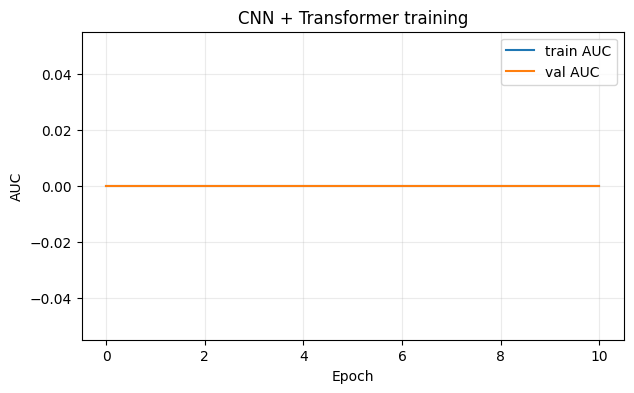

In [30]:

plt.figure(figsize=(7,4))
plt.plot(history.history["auc"], label="train AUC")
plt.plot(history.history["val_auc"], label="val AUC")
plt.xlabel("Epoch"); plt.ylabel("AUC"); plt.title("CNN + Transformer training")
plt.legend(); plt.grid(alpha=.25); plt.show()



 CNN + Transformer

Window-level:
Accuracy                1.0
Balanced Accuracy       1.0
Precision               0.0
Sensitivity / Recall    0.0
Specificity             1.0
F1                      0.0
ROC-AUC                 NaN
PR-AUC                  NaN
dtype: float64

Subject-level (mean probability across windows):
Accuracy                1.0
Balanced Accuracy       1.0
Precision               0.0
Sensitivity / Recall    0.0
Specificity             1.0
F1                      0.0
ROC-AUC                 NaN
PR-AUC                  NaN
dtype: float64

Subject confusion matrix:
[[1 0]
 [0 0]]


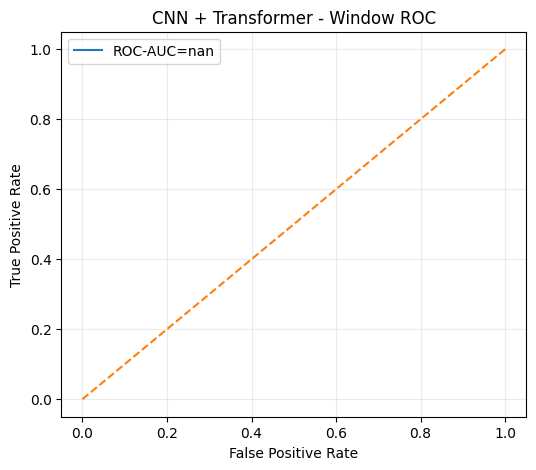

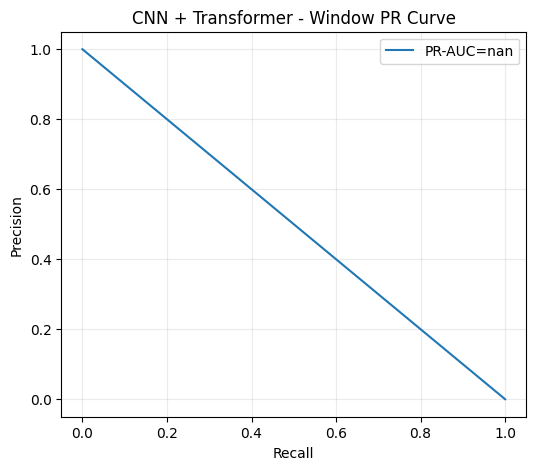

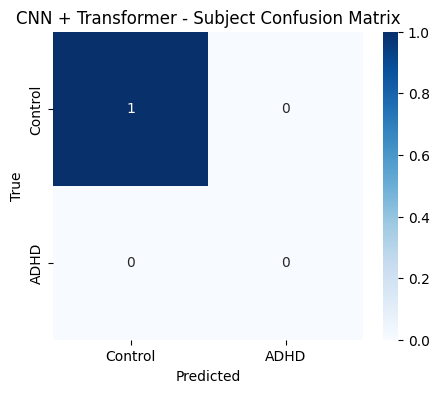

In [31]:
transformer_win_metrics, transformer_sub_metrics, transformer_subject_results = evaluate_model(model, X_test, y_test, sid_test, 'CNN + Transformer')

## Transformer attention visualization

This visualization extracts the first multi-head self-attention layer for one test window. Attention is a model-internal signal and should not be interpreted as a clinical biomarker by itself.

In [32]:

# Locate the first MultiHeadAttention layer.
mha_layers = [l for l in model.layers if isinstance(l, layers.MultiHeadAttention)]
if mha_layers:
    mha = mha_layers[0]
    attention_extractor = keras.Model(model.input, mha(model.layers[-1].input, model.layers[-1].input, return_attention_scores=True)[1])
    print("The model contains", len(mha_layers), "MultiHeadAttention layer(s).")
    print("For a full per-layer attention extraction, inspect the Keras graph above; "
          "the training/evaluation pipeline remains the primary result.")
else:
    print("No MultiHeadAttention layer found.")


No MultiHeadAttention layer found.


In [33]:

# =========================
# 14. Prediction + confidence
# =========================
def prediction_from_windows(model, X):
    prob = float(model.predict(X, verbose=0).ravel().mean())
    label = "ADHD" if prob >= 0.5 else "Control"
    confidence = prob if prob >= 0.5 else 1 - prob
    # Binary entropy, normalized to [0,1]. Lower = more certain.
    eps = 1e-7
    entropy = -(prob*np.log(prob+eps) + (1-prob)*np.log(1-prob+eps))
    return {
        "prediction": label,
        "ADHD_probability": prob,
        "Control_probability": 1-prob,
        "confidence": confidence,
        "normalized_entropy": entropy / np.log(2)
    }

print("Example test-subject prediction:")
example_sid = sid_test[0]
idx = np.where(sid_test == example_sid)[0]
print(prediction_from_windows(model, X_test[idx]))


Example test-subject prediction:
{'prediction': 'Control', 'ADHD_probability': 1.7294355814101436e-07, 'Control_probability': 0.9999998270564419, 'confidence': 0.9999998270564419, 'normalized_entropy': np.float64(3.8762512513922135e-06)}


## Final checklist

1. Confirm the validator shows the expected subjects, labels, channel count and sampling rate.
2. Confirm train/validation/test **subject IDs do not overlap**.
3. Confirm scaling was fitted only on training recordings.
4. Report **subject-level** metrics in the project/paper; window-level metrics are supplementary.
5. Do not claim a target accuracy before running the held-out test subjects.
6. For a new clinical dataset, verify its montage, sampling rate and label definitions before trusting the prediction.